In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression as SklearnLR
from sklearn.preprocessing import StandardScaler

## Data Preprocessing

In [26]:
class StandardScaler:
    def __init__(self):
        self.mean = None
        self.std = None
    def is_fitted(self):
        if self.mean is None or self.std is None:
            raise ValueError("Call fit() before transform().")
    def fit(self,X):
        self.mean = X.mean(axis=0)
        self.std = X.std(axis=0)
        self.std[self.std == 0] =1
        return self
    def transform(self,X):
        self.is_fitted()
        return (X - self.mean)/self.std
    def fit_transform(self,X):
        return self.fit(X).transform(X)
    def inv_transform(self,X_std):
        self.is_fitted()
        return (X_std*self.std) +self.mean
        

In [9]:
class Pipeline:

    def __init__(self, *steps):
        self.steps = steps

    def fit(self, X, y):
        for step in self.steps[:-1]:
            X = step.fit_transform(X)

        self.steps[-1].fit(X, y)
        return self

    def predict(self, X):
        for step in self.steps[:-1]:
            X = step.transform(X)

        return self.steps[-1].predict(X)

# Linear Models

## Linear regression

In [3]:
class LinearRegressionOwn:
    def __init__(self,learning_rate =0.01,epoch=10000,tol=1e-6,patience =20):
        self.weights = None
        self.bias = None
        self.learning_rate =learning_rate
        self.epoch = epoch
        self.tol = tol
        self.patience = patience
        self.loss_history = []
    def init_parameters(self,n):
        self.weights = np.zeros((n,1))
        self.bias = 0.0
    def update_parameters(self,dw,db):
        self.weights = self.weights - self.learning_rate*dw
        self.bias = self.bias - self.learning_rate*db
    def compute_gradients(self,X,error):
        m= X.shape[0]
        return (X.T @ error)/m , np.sum(error)/m
    def predict(self ,X):
        return np.dot(X , self.weights)+self.bias
    def find_early_stopping(self,cost,count,prev_cost):
        stop=False
        if prev_cost is not None and abs(prev_cost - cost) < self.tol:
            if count < self.patience:
                count+=1
            else:
                count = 0
                stop =True
        else:
            count = 0
        return stop,count
            
    def train_epoch(self,X,y):
        raise NotImplementedError()
    def fit(self, X,y):
        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y have different number of samples.")
        m,n = X.shape
        self.init_parameters(n)
        prev_cost = None
        count=0
        for _ in range(self.epoch):
            cost = self.train_epoch(X,y)
            stop , count = self.find_early_stopping(cost,count,prev_cost)
            if stop:
                print("model is converged")
                break
            prev_cost = cost
            self.loss_history.append(cost)
        return self


            
    

## Batch GD Regression

In [12]:
class BatchGD(LinearRegressionOwn):
    def __init__(self,learning_rate =0.01,epoch=10000,tol=1e-6,patience =20):
        super().__init__(learning_rate =learning_rate,epoch=epoch,tol=tol,patience =patience)
    def train_epoch(self,X,y):
        y_pred = self.predict(X)
        error = y_pred -y
        cost = np.mean(error**2)/2
        dw,db = self.compute_gradients(X,error)
        self.update_parameters(dw,db)
        return cost


## SGD Regression

In [14]:
class SGD(LinearRegressionOwn):
    def __init__(self,learning_rate =0.01,epoch=10000,tol=1e-6,patience =20):
        super().__init__(learning_rate =learning_rate,epoch=epoch,tol=tol,patience =patience)
    def train_epoch(self,X,y):
        m = X.shape[0]
        idx = np.random.permutation(m)
        X_shuffle = X[idx]
        y_shuffle= y[idx]
        cost = 0
        for i in range(m):
            x_i = X_shuffle[i:i+1]
            y_i = y_shuffle[i:i+1]
            pred = self.predict(x_i)
            error = pred -y_i
            cost += np.mean(error**2)/2
            dw,db = self.compute_gradients(x_i,error)
            self.update_parameters(dw,db)
        return cost/m

## MiniBatchGD regression

In [16]:
class MiniBatchGD(LinearRegressionOwn):
    def __init__(self,learning_rate =0.01,epoch=10000,tol=1e-6,patience =20,batch_size = 32):
        self.batch_size =batch_size
        super().__init__(learning_rate =learning_rate,epoch=epoch,tol=tol,patience =patience)
    def train_epoch(self,X,y):
        m = X.shape[0]
        idx = np.random.permutation(m)
        X_shuffle = X[idx]
        y_shuffle= y[idx]
        cost = 0
        n_iter=0
        for i in range(0,m,self.batch_size):
            x_batch = X_shuffle[i:i+self.batch_size]
            y_batch = y_shuffle[i:i+self.batch_size]
            pred = self.predict(x_batch)
            error = pred -y_batch
            cost += np.mean(error**2)/2
            dw,db = self.compute_gradients(x_batch,error)
            self.update_parameters(dw,db)
            n_iter+=1
        return cost/n_iter

## Linear Regression Analytical Method Normal Equation , SVD , PSUEDO INVERSE (PINV)

In [28]:
class NormalEquation():
    def __init__(self):
        self.weights = None
        self.bias =None
    def check_len(self,X,y):
        if X.shape[0] != y.shape[0]:
            raise ValueError("X and y length mismatch.")
    def fit(self,X,y):
        self.check_len(X,y)
        m= X.shape[0]
        X = np.c_[np.ones((m,1)), X]
        theta = np.linalg.pinv(X.T@X) @X.T@y
        self.bias = float(theta[0])
        self.weights = theta[1:]
        return self
        
    def fit_svd(self, X, y):
        self.check_len(X,y)
        m = X.shape[0]
        X = np.c_[np.ones((m,1)), X]
        U, S, VT = np.linalg.svd(X, full_matrices=False)
        S_inv = np.diag(1 / S)
        theta = VT.T @ S_inv @ U.T @ y
        self.bias = float(theta[0])
        self.weights = theta[1:]
        return self

    def fit_pinv(self , X,y):
        self.check_len(X,y)
        X = np.c_[np.ones(x.shape[0],1) , X]
        theta = np.linalg.pinv(X) @ y
        self.bias = theta[0]
        self.weights = theta[1:]
        return self
        
    def predict(self,X):
        return (X @ self.weights) + self.bias

## Ridge Regression L2 Norm Regularization

In [22]:
class RidgeRegression(LinearRegressionOwn):
    def __init__(self,learning_rate =0.01 ,epoch=1000,tol = 1e-10,patience =20,alpha = 100):
        self.alpha =alpha
        super().__init__(learning_rate=learning_rate,epoch=epoch,tol=tol,patience=patience)
    def compute_cost(self,error):
        m  = error.shape[0]
        cost = np.sum(error**2)/(2*m)
        ridge_penalty = self.alpha*np.sum(self.weights**2)/(2*m)
        return cost + ridge_penalty
    def compute_gradients(self,X,error):
        m = X.shape[0]
        dw = (X.T @ error)/m + self.alpha/m * self.weights
        db = np.mean(error)
        return dw,db

## Lasso Regression L1 Norm Regularization Co ordinate Descent

In [23]:
class Lasso(LinearRegressionOwn):
    def __init__(self,learning_rate =0.01,epoch=1000,tol=1e-10,patience =20,alpha = 100):
        self.alpha = alpha
        super().__init__(learning_rate =learning_rate , epoch =epoch,tol =tol , patience =patience)        
    def soft_thresholding(self,rho):
        if rho > self.alpha:
            return rho - self.alpha
        elif rho < -self.alpha:
            return rho + self.alpha
        else:
            return 0.0
    def fit(self,X,y):
        if X.shape[0] != y.shape[0]:
            raise ValueError("rows length mismatch")
        m,n = X.shape
        self.init_parameters(n)
        count = 0
        for _ in range(self.epoch):
            old_weights = self.weights.copy()
            for j in range(n):
                pred = (X @ self.weights)+ self.bias
                rj = y- pred + (X[:,[j]] * self.weights[j])
                rho_j = self.soft_thresholding((X[:,[j]].T @ rj).item())
                z_j = X[:,[j]].T @ X[:,[j]]
                self.weights[j] = rho_j/z_j.item()
            self.bias = np.mean(y - (X @ self.weights))
            if np.max(np.abs(old_weights-self.weights)) < self.tol:
                if count < self.patience:
                    count+=1
                else:
                    print("model converged")
                    count= 0
                    break
            else:
                count=0
        return self
    

## Elastic Net regression - L1 + L2 Norm - Coordinate Descent

In [25]:
class ElasticNet(LinearRegressionOwn):
    def __init__(self,learning_rate=0.01,epoch=1000,tol=1e-5,patience=10,alpha = 100,l1_ratio=0.5):
        self.alpha = alpha
        self.l1_ratio =l1_ratio
        super().__init__(
            learning_rate=learning_rate,
            epoch=epoch,
            tol=tol,
            patience=patience
            )
    def soft_thresholding(self,rho):
        threshold = self.alpha*self.l1_ratio
        if rho > threshold:
            return rho - threshold
        elif rho < -threshold:
            return rho + threshold
        else:
            return 0.0
    def fit(self,X,y):
        if X.shape[0] != y.shape[0]:
            raise ValueError("X,y length mismatch")
        m,n = X.shape
        self.init_parameters(n)
        count = 0
        for _ in range(self.epoch):
            old_weights =self.weights.copy()
            for j in range(n):
                pred =X @ self.weights + self.bias
                rj = y -pred + (X[:,[j]]  * self.weights[j])
                rho_j = (X[:,[j]].T @ rj).item()
                rho_j = self.soft_thresholding(rho_j)
                z_j = X[:,[j]].T @ X[: ,[j]]
                ridge_term = self.alpha *(1-self.l1_ratio)
                denom = z_j + ridge_term
                self.weights[j] =rho_j/denom
            self.bias = np.mean(y - (X @ self.weights))
            if np.max(np.abs(old_weights - self.weights)) < self.tol:
                if count <  self.patience:
                    count+=1
                else:
                    count=0
                    break
            else:
                count = 0
        return self
                
                
                
                
                

                

## Learning Rate Finder Algorithm Plotting

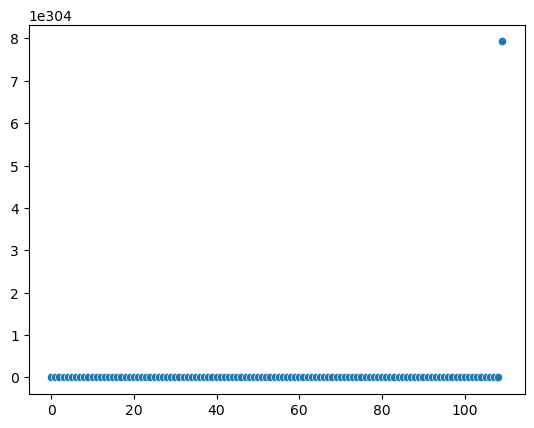

In [155]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.scatterplot(x = range(len(lr2.loss_history))  , y = lr2.loss_history)
plt.show()


In [146]:
lr2.bias

np.float64(487.0106771914966)

In [147]:
lr2.weights

array([[   4.42996548],
       [-118.04161238]])

In [154]:
lr2 = LinearRegression1()
lr2.fit(new_X.reshape(-1,2) , y.reshape(-1,1))

#lr2.predict(new_X.reshape(-1,2))


277.17443072530835 322.80846524651434
-7.105427357601002e-17 0.9999999999999999


/var/folders/y8/g73tz4697hjc1mg8sh17rpy40000gn/T/ipykernel_2832/1534785907.py:21: RuntimeWarning: overflow encountered in square
  cost = np.sum(error**2)/(2*m)
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/var/folders/y8/g73tz4697hjc1mg8sh17rpy40000gn/T/ipykernel_2832/1534785907.py:23: RuntimeWarning: invalid value encountered in scalar subtract
  if abs(prev_cost - cost) < self.tol:
/var/folders/y8/g73tz4697hjc1mg8sh17rpy40000gn/T/ipykernel_2832/1534785907.py:26: RuntimeWarning: overflow encountered in dot
  dj_dw = np.dot(X.T, error)/m
/var/folders/y8/g73tz4697hjc1mg8sh17rpy40000gn/T/ipykernel_2832/1534785907.py:19: RuntimeWarning: invalid value encountered in dot
  y_pred = np.dot(X,self.weights)+self.bias


In [126]:
#X = np.array([[1],[2],[3],[4],[5],[6],[7]])
#y = np.array([[8,9,10,11,12,13,14]])
lr = LinearRegression1()
lr.fit(np.array(df['x']).reshape(-1,1),np.array(df['y']).reshape(-1,1))
print(lr.weights , lr.bias)
lr.predict(np.array(df['x']).reshape(-1,1))


2.0 0.816496580927726
0.0 0.9999999999999999
[[0.81616092]] 6.99712231178306


array([[7.81328323],
       [8.62944415],
       [9.44560507]])

In [120]:
lr.loss_history

[np.float64(24.833333333333332),
 np.float64(24.33915),
 np.float64(23.854800915),
 np.float64(23.3800903767915),
 np.float64(22.914826578293347),
 np.float64(22.458821529385308),
 np.float64(22.011890980950543),
 np.float64(21.573854350429627),
 np.float64(21.14453464885608),
 np.float64(20.72375840934384),
 np.float64(20.3113556169979),
 np.float64(19.907159640219643),
 np.float64(19.511007163379272),
 np.float64(19.12273812082802),
 np.float64(18.742195632223545),
 np.float64(18.369225939142297),
 np.float64(18.003678342953364),
 np.float64(17.645405143928595),
 np.float64(17.294261581564413),
 np.float64(16.950105776091284),
 np.float64(16.61279867114706),
 np.float64(16.282203977591237),
 np.float64(15.958188118437173),
 np.float64(15.640620174880274),
 np.float64(15.329371833400153),
 np.float64(15.02431733391549),
 np.float64(14.725333418970573),
 np.float64(14.43229928393306),
 np.float64(14.14509652818279),
 np.float64(13.863609107271955),
 np.float64(13.58772328603724),
 np.f

In [58]:
df = pd.DataFrame([(1,6),(2,7) ,(3,8)] , columns= ['x','y'])

In [60]:
np.array(df['x']).reshape(-1,1).shape

(3, 1)

In [62]:
np.array(df['x']).reshape(-1,1)

array([[1],
       [2],
       [3]])

In [177]:
import numpy as np
import matplotlib.pyplot as plt
import numpy as np


class LinearRegression:

    def __init__(self):

        self.w = np.zeros((1,1))
        self.b = 0

    def initialize(self, n_features):

        self.w = np.zeros(n_features)
        self.b = 0

    def predict(self, X):

        return np.dot(X, self.w) + self.b

    def compute_loss(self, y, predictions):

        return np.mean((y - predictions) ** 2)

    def compute_gradients(self, X, y):

        m = len(y)

        predictions = self.predict(X)

        dw = (-2/m) * np.dot(X.T, (y - predictions))

        db = (-2/m) * np.sum(y - predictions)

        return dw, db

    def update_parameters(self, dw, db, lr):

        self.w -= lr * dw
        self.b -= lr * db


class LearningRateFinder:

    def __init__(self,
                 model,
                 start_lr=1e-7,
                 end_lr=10,
                 num_iterations=100):

        self.model = model

        self.start_lr = start_lr
        self.end_lr = end_lr
        self.num_iterations = num_iterations

        self.learning_rates = []
        self.losses = []

    def find(self, X, y):

        # Exponential multiplier
        multiplier = (self.end_lr / self.start_lr) ** (
            1 / self.num_iterations
        )

        lr = self.start_lr

        best_loss = np.inf

        for iteration in range(self.num_iterations):

            # Forward pass
            predictions = self.model.predict(X)

            # Compute loss
            loss = self.model.compute_loss(y, predictions)
            self.learning_rates.append(lr)
            self.losses.append(loss)
            #print(loss)
            # Stop if loss diverges
            if np.isnan(loss) or np.isinf(loss):
                print("Training diverged.")
                break

            if loss > 4 * best_loss:
                print("Loss exploded.")
                break

            best_loss = min(best_loss, loss)

            # Compute gradients
            dw, db = self.model.compute_gradients(X, y)

            # Update parameters
            self.model.update_parameters(dw, db, lr)

            # Increase learning rate
            lr *= multiplier

        return self.learning_rates, self.losses

    def plot(self):

        plt.figure(figsize=(8,5))
        plt.plot(self.learning_rates, self.losses)

        plt.xscale("log")

        plt.xlabel("Learning Rate")
        plt.ylabel("Loss")
        plt.title("Learning Rate Range Test")

        plt.grid(True)

        plt.show()

In [178]:
lrf = LearningRateFinder(LinearRegression())

In [179]:
lrf.find(np.array(df['x']).reshape(-1,1),np.array(df['y']).reshape(-1,1))

49.666666666666664
49.66656102228077
49.666434010088636
49.66628130827478
49.66609772093281
49.66587700129409
49.665611639213466
49.66529260568772
49.66490904572358
49.66444790911891
49.66389350661501
49.66322697634762
49.66242564248625
49.66146224430236
49.66030400952744
49.658911540604606
49.657237476132195
49.65522488223419
49.65280531953016
49.649896520520166
49.646399599208515
49.64219569925418
49.63714196838154
49.63106672465574
49.623763653878136
49.614984846050014
49.60443244174812
49.59174861541749
49.57650357099521
49.558181164856364
49.53616170073951
49.509701360077315
49.47790763828025
49.43971005273383
49.393825272155816
49.33871569150122
49.27254034599704
49.19309692973844
49.0977535713084
48.98336894137875
48.84619925647985
48.68179084605566
48.484857235604956
48.24914026672667
47.96725576611686
47.6305258853136
47.228802725798744
46.75029158815878
46.1813875807573
45.50654692272794
44.708224661425334
43.766924238628036
42.661421687399454
41.36924792046635
39.86753504309

([1e-07,
  1.202264434617413e-07,
  1.4454397707459276e-07,
  1.7378008287493757e-07,
  2.0892961308540398e-07,
  2.5118864315095807e-07,
  3.019951720402017e-07,
  3.6307805477010147e-07,
  4.3651583224016615e-07,
  5.248074602497729e-07,
  6.309573444801936e-07,
  7.585775750291842e-07,
  9.120108393559103e-07,
  1.0964781961431857e-06,
  1.318256738556408e-06,
  1.5848931924611147e-06,
  1.9054607179632488e-06,
  2.290867652767775e-06,
  2.754228703338169e-06,
  3.311311214825914e-06,
  3.981071705534977e-06,
  4.7863009232263885e-06,
  5.754399373371575e-06,
  6.918309709189372e-06,
  8.31763771102672e-06,
  1.0000000000000011e-05,
  1.2022644346174142e-05,
  1.445439770745929e-05,
  1.7378008287493774e-05,
  2.089296130854042e-05,
  2.5118864315095832e-05,
  3.01995172040202e-05,
  3.630780547701018e-05,
  4.3651583224016654e-05,
  5.248074602497733e-05,
  6.309573444801941e-05,
  7.58577575029185e-05,
  9.120108393559111e-05,
  0.00010964781961431868,
  0.00013182567385564093,
  

In [162]:
lr = LinearRegression() 

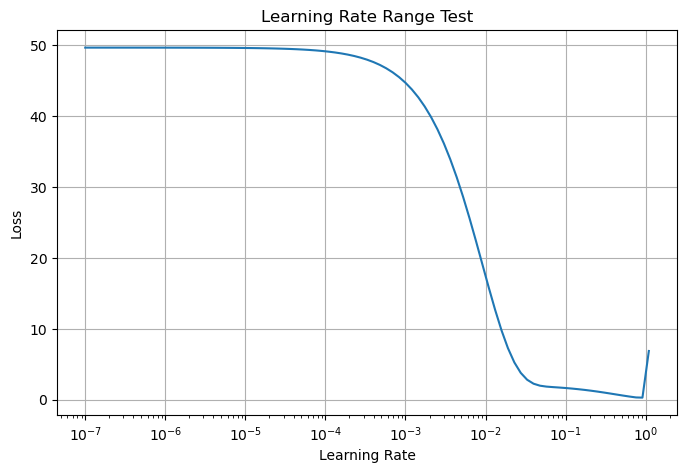

In [180]:
lrf.plot()

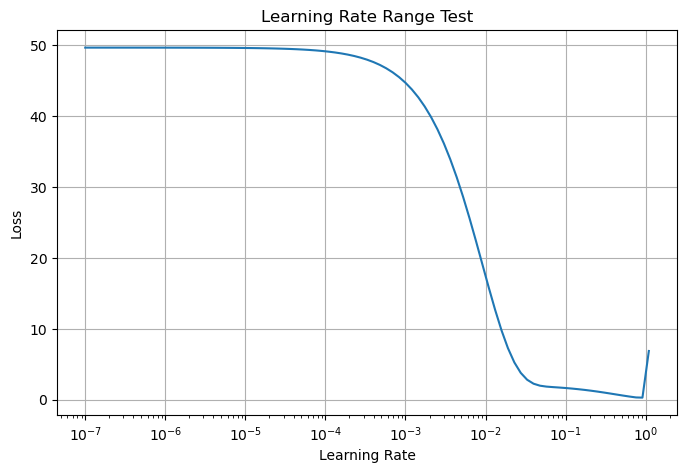

In [180]:
lrf.plot()

## Random search

In [208]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

param_distributions = {
    'alpha': np.linspace(0.1, 10.0, num=10).tolist(),       # Continuous uniform distribution between 0.01 and 100.01
    'fit_intercept': [True, False]      # Discrete boolean choices
}

# 4. Initialize and run Random Search
# n_iter=50 means it will randomly pick 50 combinations
random_search = RandomizedSearchCV(
    estimator=SGDRegressor(), 
    param_distributions=param_distributions, 
    n_iter=50, 
    scoring='neg_mean_squared_log_error',  
    random_state=42,
    cv=2,
    n_jobs=-1
)

In [209]:
random_search.fit(np.array(df['x']).reshape(-1,1),np.array(df['y']).reshape(-1,1))


/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/anaconda3/envs/ml_env/lib/python3.11/site-packages/sklearn/utils/validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was e

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SGDRegressor()
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'alpha': [0.1, 1.2000000000000002, ...], 'fit_intercept': [True, False]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",50
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_squared_log_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None c